In [1]:
import yfinance as yf
import pandas as pd
print("Libraries working!")

Libraries working!


In [3]:
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

In [4]:
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [5]:
import requests
from bs4 import BeautifulSoup

In [6]:
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html_data = requests.get(url).text

soup = BeautifulSoup(html_data, "html.parser")


In [10]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# Step 1: Get page content
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html_data = requests.get(url).text

# Step 2: Parse HTML
soup = BeautifulSoup(html_data, "html.parser")

# Step 3: Find all tables and pick the one that contains 'Tesla Quarterly Revenue'
tables = soup.find_all("table")

tesla_revenue = None
for table in tables:
    if "Quarterly Revenue" in table.text:  # more flexible check
        tesla_revenue = pd.read_html(str(table))[0]
        break

# Step 4: Verify and clean
if tesla_revenue is not None:
    tesla_revenue.columns = ["Date", "Revenue"]
    tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace("$", "").str.replace(",", "")
    tesla_revenue.dropna(inplace=True)
    display(tesla_revenue.tail())  # shows last 5 rows
else:
    print("Tesla revenue table not found. Try inspecting the webpage manually.")


Tesla revenue table not found. Try inspecting the webpage manually.


In [12]:
import pandas as pd
import requests

url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers = {"User-Agent": "Mozilla/5.0"}
html_data = requests.get(url, headers=headers).text

# Read all tables from the page
from io import StringIO
tables = pd.read_html(StringIO(html_data))

tesla_revenue = tables[1] if len(tables) > 1 else tables[0]

# Clean it
tesla_revenue.columns = ["Date", "Revenue"]
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace("$", "").str.replace(",", "")
tesla_revenue.dropna(inplace=True)

# Show last 5 rows
display(tesla_revenue.tail())

,Date,Revenue
54,2011-12-31,39
55,2011-09-30,58
56,2011-06-30,58
57,2011-03-31,49
58,2010-12-31,36


In [13]:
# Import yfinance library
import yfinance as yf
import pandas as pd

# Download GameStop (GME) stock data using yfinance
gme = yf.Ticker("GME")

# Extract historical data for the maximum available period
gme_data = gme.history(period="max")

# Reset the index to make 'Date' a column instead of an index
gme_data.reset_index(inplace=True)

# Display the first five rows
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [16]:
import pandas as pd
import requests
from io import StringIO

# Step 1: Get the webpage content
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
headers = {"User-Agent": "Mozilla/5.0"}
html_data = requests.get(url, headers=headers).text

# Step 2: Read all tables from the HTML
tables = pd.read_html(StringIO(html_data))

# Step 3: Pick the correct table
gme_revenue = tables[1] if len(tables) > 1 else tables[0]

# Step 4: Clean the table
gme_revenue.columns = ["Date", "Revenue"]
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "").str.replace(",", "")
gme_revenue.dropna(inplace=True)

# Step 5: Display the last 5 rows
display(gme_revenue.tail())


,Date,Revenue
54,2012-01-31,3579
55,2011-10-31,1947
56,2011-07-31,1744
57,2011-04-30,2281
58,2011-01-31,3693


In [17]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock_name):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot stock prices
    ax1.plot(stock_data['Date'], stock_data['Close'], color='tab:blue', label='Stock Price')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Stock Price (USD)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Create a twin y-axis for revenue
    ax2 = ax1.twinx()
    ax2.plot(revenue_data['Date'], revenue_data['Revenue'], color='tab:red', label='Revenue')
    ax2.set_ylabel("Revenue (USD)", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Add title and layout
    plt.title(f"{stock_name} Stock Price vs Revenue")
    fig.tight_layout()
    plt.show()


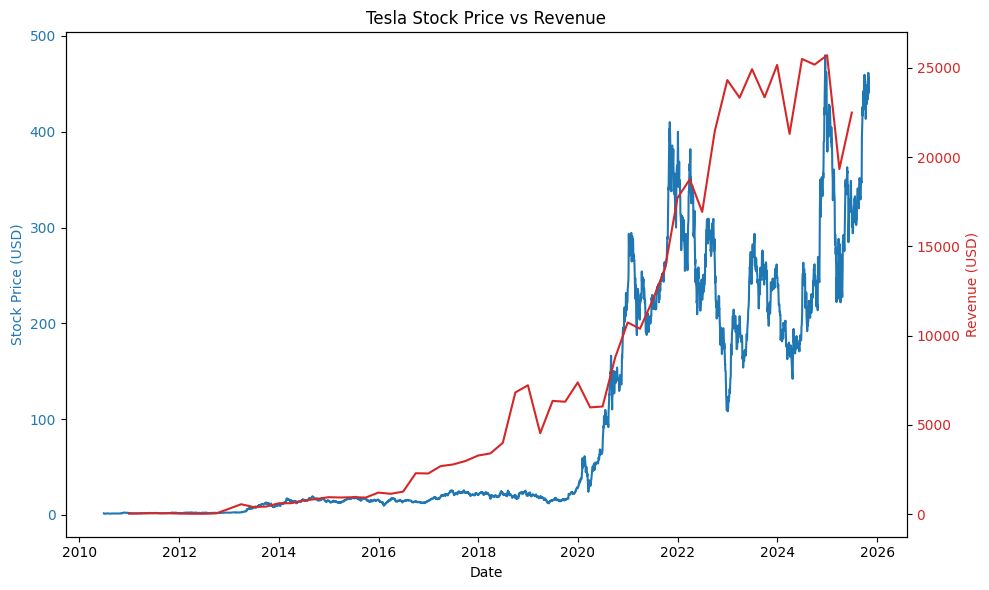

In [18]:
# Convert Tesla revenue to numeric (in case any non-numeric values remain)
tesla_revenue["Revenue"] = pd.to_numeric(tesla_revenue["Revenue"], errors="coerce")

# Filter Tesla stock data to match available revenue timeline
tesla_data["Date"] = pd.to_datetime(tesla_data["Date"])
tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"])

# Call the graph function
make_graph(tesla_data, tesla_revenue, "Tesla")


In [19]:
# Ensure columns are in the right format
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "").str.replace(",", "")
gme_revenue["Revenue"] = pd.to_numeric(gme_revenue["Revenue"], errors="coerce")

# Convert date columns to datetime for plotting
gme_data["Date"] = pd.to_datetime(gme_data["Date"])
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])


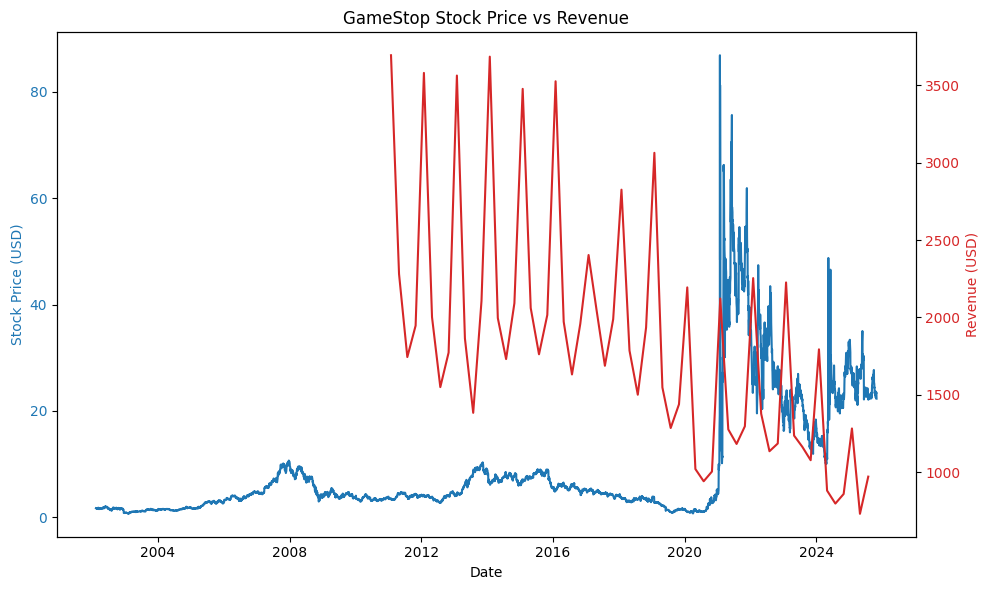

In [20]:
make_graph(gme_data, gme_revenue, "GameStop")